In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

In [5]:
df = pd.read_csv('data/data_cleaned.csv')
print(df)

      Time  Indoor Temp  Weather Temp      CO2  Relative Humidity  Lighting  \
0     1145      18.1875        0.0000  216.560            39.9125   81.6650   
1     1200      18.4633        6.8000  219.947            39.9267   81.7413   
2     1215      18.7673       17.0000  219.403            39.7720   81.4240   
3     1230      19.0727       18.0000  218.613            39.7760   81.5013   
4     1245      19.3721       20.0000  217.714            39.7757   81.4657   
...    ...          ...           ...      ...                ...       ...   
4132   630      18.8000       11.0000  199.424            43.0160   21.8500   
4133   645      18.7713       11.7333  199.200            43.1920   21.1653   
4134   700      18.7860       12.0000  199.435            43.3947   21.2640   
4135   715      18.8133       12.5333  200.107            43.3440   28.1647   
4136   730      18.8600       13.0000  200.149            43.6667   31.1107   

      Rain      Sun      Wind  Sunlight(West)  Sunl

In [6]:
correlations = df.corr()['CO2'].drop('CO2')
print(correlations)

Time                         0.011550
Indoor Temp                 -0.004932
Weather Temp                 0.065182
Relative Humidity            0.007569
Lighting                     0.210973
Rain                        -0.077145
Sun                          0.118342
Wind                         0.016163
Sunlight(West)               0.139729
Sunlight(East)               0.024964
Sunlight(South)              0.266481
Sun Irradiance               0.202645
Outdoor Temp                 0.059812
Outdoor Relative Humidity   -0.024068
Name: CO2, dtype: float64


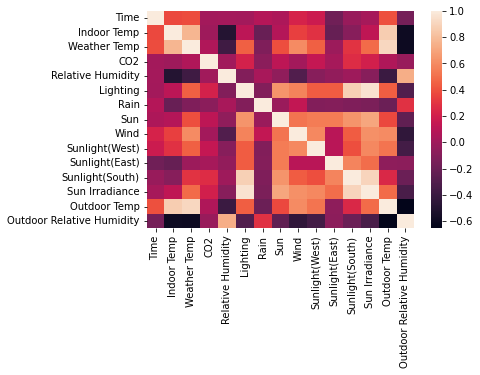

In [9]:
sns.heatmap(df.corr())
plt.show()

In [10]:
def get_features(correlation_threshold):
    abs_corrs = correlations.abs()
    high_correlations = abs_corrs[abs_corrs > correlation_threshold].index.values.tolist()
    return high_correlations

In [11]:
features = get_features(0.05) 
print(features) 
X = df[features] 
y = df['CO2']

['Weather Temp', 'Lighting', 'Rain', 'Sun', 'Sunlight(West)', 'Sunlight(South)', 'Sun Irradiance', 'Outdoor Temp']


In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=99)

In [15]:
# Fit linear regression to training data
lr = LinearRegression()
lr.fit(X_train,y_train)

# Predict
train_pred=lr.predict(X_train)
lr_pred = lr.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, lr_pred))
print('Mean Squared Error:', mean_squared_error(y_test, lr_pred))

Mean Absolute Error: 8.883484849517911
Mean Squared Error: 559.1781436799605


In [16]:
# displaying coefficients of each feature
coeffecients = pd.DataFrame(lr.coef_,features)
coeffecients.columns = ['Coeffecient'] 
print(coeffecients)

                 Coeffecient
Weather Temp        0.151383
Lighting            0.371981
Rain               -5.256363
Sun                -0.004947
Sunlight(West)      0.000243
Sunlight(South)     0.000434
Sun Irradiance     -0.061513
Outdoor Temp       -0.015458


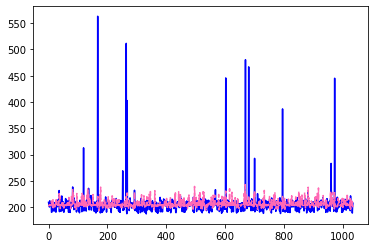

In [43]:
y_test.reset_index(inplace=True, drop=True)
plt.plot(y_test, 'b')
plt.plot(lr_pred, ls = '--', color='hotpink')
plt.legend
plt.show()

In [19]:
alphas = 10**np.linspace(10,-2,100)*0.5
ridgecv = RidgeCV(alphas = alphas, scoring = 'neg_mean_squared_error')
ridgecv.fit(X_train, y_train)
ridgecv.alpha_

1.7555958671075638

In [20]:
ridge = Ridge(alpha = ridgecv.alpha_, normalize = True)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, ridge_pred))
print('Mean Squared Error:', mean_squared_error(y_test, ridge_pred))

Mean Absolute Error: 8.191928511217201
Mean Squared Error: 589.7048318316051


C:\Users\cavlo\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Ridge())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * n_samples. 
  warnings.warn(


In [21]:
# displaying coefficients of each feature
coeffecients = pd.DataFrame(ridge.coef_,features)
coeffecients.columns = ['Coeffecient'] 
print(coeffecients)

                 Coeffecient
Weather Temp        0.004426
Lighting            0.031273
Rain               -2.576673
Sun                 0.000474
Sunlight(West)      0.000031
Sunlight(South)     0.000049
Sun Irradiance      0.002031
Outdoor Temp       -0.010842


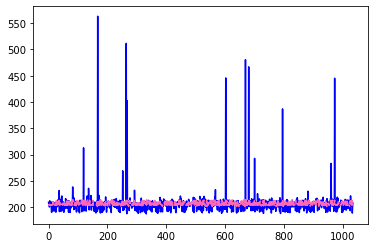

In [44]:
plt.plot(y_test, 'b')
plt.plot(ridge_pred, ls = '--', color='hotpink')
plt.legend
plt.show()

In [22]:
lassocv = LassoCV(alphas=None, cv=10, max_iter=100000, normalize = True)
lassocv.fit(X_train, y_train)
lassocv.alpha_

C:\Users\cavlo\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Lasso())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * np.sqrt(n_samples). 
  warnings.warn(


0.00011831802142751233

In [23]:
lasso = Lasso(alpha = lassocv.alpha_, normalize = True)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, lasso_pred))
print('Mean Squared Error:', mean_squared_error(y_test, lasso_pred))

Mean Absolute Error: 8.86731987222539
Mean Squared Error: 559.094081185714


C:\Users\cavlo\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Lasso())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * np.sqrt(n_samples). 
  warnings.warn(


In [24]:
# displaying coefficients of each feature
coeffecients = pd.DataFrame(lasso.coef_,features)
coeffecients.columns = ['Coeffecient'] 
print(coeffecients)

                 Coeffecient
Weather Temp        0.134328
Lighting            0.361646
Rain               -5.183620
Sun                -0.004918
Sunlight(West)      0.000239
Sunlight(South)     0.000431
Sun Irradiance     -0.060218
Outdoor Temp       -0.000000


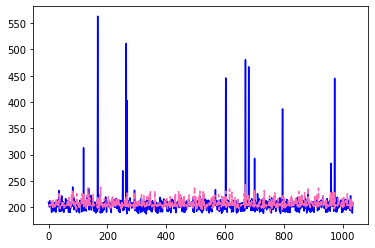

In [45]:
plt.plot(y_test, 'b')
plt.plot(lasso_pred, ls = '--', color='hotpink')
plt.legend
plt.show()